## Load Cleaned Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:/OneDrive/+Study/C Projects/fintech-credit-risk-model/Data/processed/cleaned_loans.csv")

df.shape
df.head()

,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,...,issue_d,open_acc,pub_rec,revol_bal,revol_util,total_acc,earliest_cr_line,application_type,addr_state,target_default
0,3600.0,36 months,13.99,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,...,Dec-2015,7.0,0.0,2765.0,29.7,13.0,Aug-2003,Individual,PA,0
1,24700.0,36 months,11.99,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,...,Dec-2015,22.0,0.0,21470.0,19.2,38.0,Dec-1999,Individual,SD,0
2,20000.0,60 months,10.78,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,...,Dec-2015,6.0,0.0,7869.0,56.2,18.0,Aug-2000,Joint App,IL,0
3,10400.0,60 months,22.45,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,...,Dec-2015,12.0,0.0,21929.0,64.5,35.0,Jun-1998,Individual,PA,0
4,11950.0,36 months,13.44,C,C3,4 years,RENT,34000.0,Source Verified,debt_consolidation,...,Dec-2015,5.0,0.0,8822.0,68.4,6.0,Oct-1987,Individual,GA,0


## Default Rate overview

In [3]:
default_rate = df["target_default"].mean()

print(f"Default Rate: {default_rate:.2%}")

Default Rate: 21.47%


This is the Portfolio baseline

## Risk by loan grade

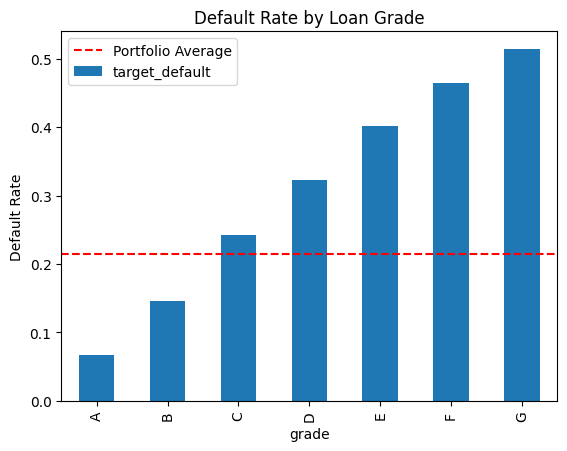

In [15]:
grade_default = (
    df.groupby("grade")["target_default"]
      .mean()
      .sort_index()
)

grade_default.plot(kind="bar")

plt.axhline(
    y=default_rate,
    color="red",
    linestyle="--",
    label="Portfolio Average"
)

plt.legend()

plt.title("Default Rate by Loan Grade")
plt.ylabel("Default Rate")

plt.show()

The monotonic increase in default rates across LendingClub grades suggests that the platform’s internal grading framework captures meaningful borrower risk differentiation.

## Risk by Interest Rate

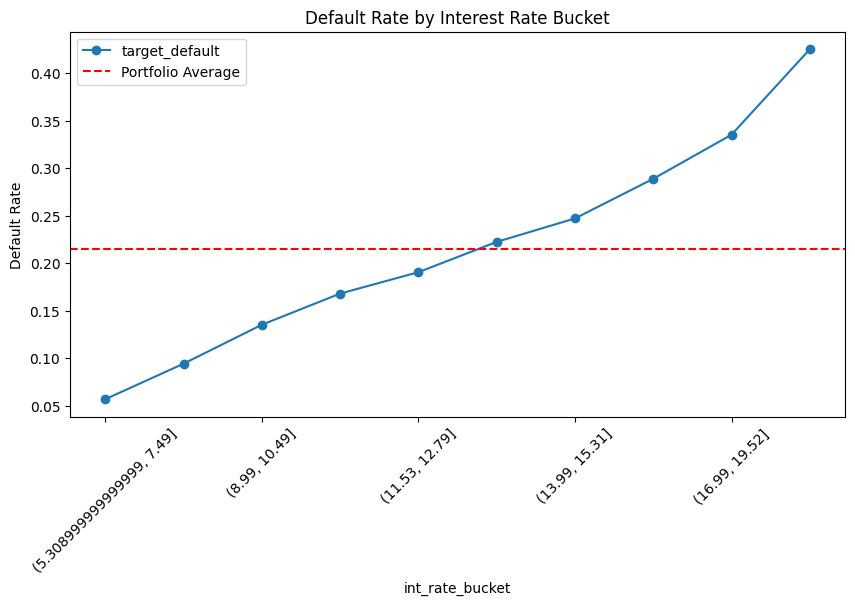

In [9]:
df["int_rate_bucket"] = pd.qcut(
    df["int_rate"],
    q=10,
    duplicates="drop"
)

int_default = (
    df.groupby("int_rate_bucket")["target_default"]
      .mean()
)

plt.figure(figsize=(10,5))

int_default.plot(marker="o")

plt.axhline(
    y=default_rate,
    color="red",
    linestyle="--",
    label="Portfolio Average"
)

plt.legend()

plt.title("Default Rate by Interest Rate Bucket")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)

plt.show()

## Risk by Loan Term

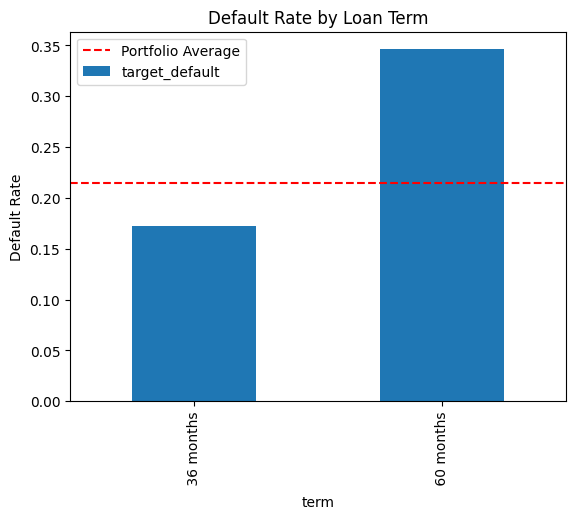

In [10]:
term_default = (
    df.groupby("term")["target_default"]
      .mean()
)

term_default.plot(kind="bar")

plt.axhline(
    y=default_rate,
    color="red",
    linestyle="--",
    label="Portfolio Average"
)

plt.legend()

plt.title("Default Rate by Loan Term")
plt.ylabel("Default Rate")

plt.show()

60-month loans default more than 36-month loans.
Longer-duration exposure increases uncertainty, economic sensitivity and repayment risk.

## Risk by DTI

In [11]:
df["dti_bucket"] = pd.qcut(
    df["dti"],
    q=10,
    duplicates="drop"
)

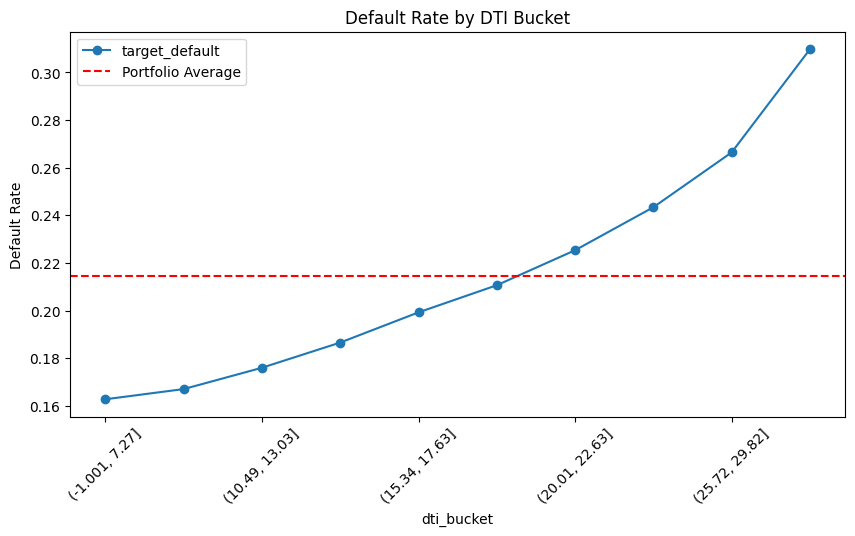

In [12]:
df["dti_bucket"] = pd.qcut(
    df["dti"],
    q=10,
    duplicates="drop"
)

dti_default = (
    df.groupby("dti_bucket")["target_default"]
      .mean()
)

plt.figure(figsize=(10,5))

dti_default.plot(marker="o")

plt.axhline(
    y=default_rate,
    color="red",
    linestyle="--",
    label="Portfolio Average"
)

plt.legend()

plt.xticks(rotation=45)

plt.title("Default Rate by DTI Bucket")
plt.ylabel("Default Rate")

plt.show()

Observe debt-to-income's relation with default rate. Higher dti represents higher debt burden, affordability stress and thus higher default rate.

## Missing values Review

In [13]:
missing_pct = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
)

missing_pct.head(20)

emp_length             5.893962e-02
revol_util             6.468947e-04
dti                    2.939104e-04
dti_bucket             2.939104e-04
inq_last_6mths         7.293063e-07
loan_amnt              0.000000e+00
term                   0.000000e+00
grade                  0.000000e+00
int_rate               0.000000e+00
verification_status    0.000000e+00
annual_inc             0.000000e+00
home_ownership         0.000000e+00
sub_grade              0.000000e+00
issue_d                0.000000e+00
open_acc               0.000000e+00
purpose                0.000000e+00
delinq_2yrs            0.000000e+00
revol_bal              0.000000e+00
pub_rec                0.000000e+00
earliest_cr_line       0.000000e+00
dtype: float64

## Corrleation review

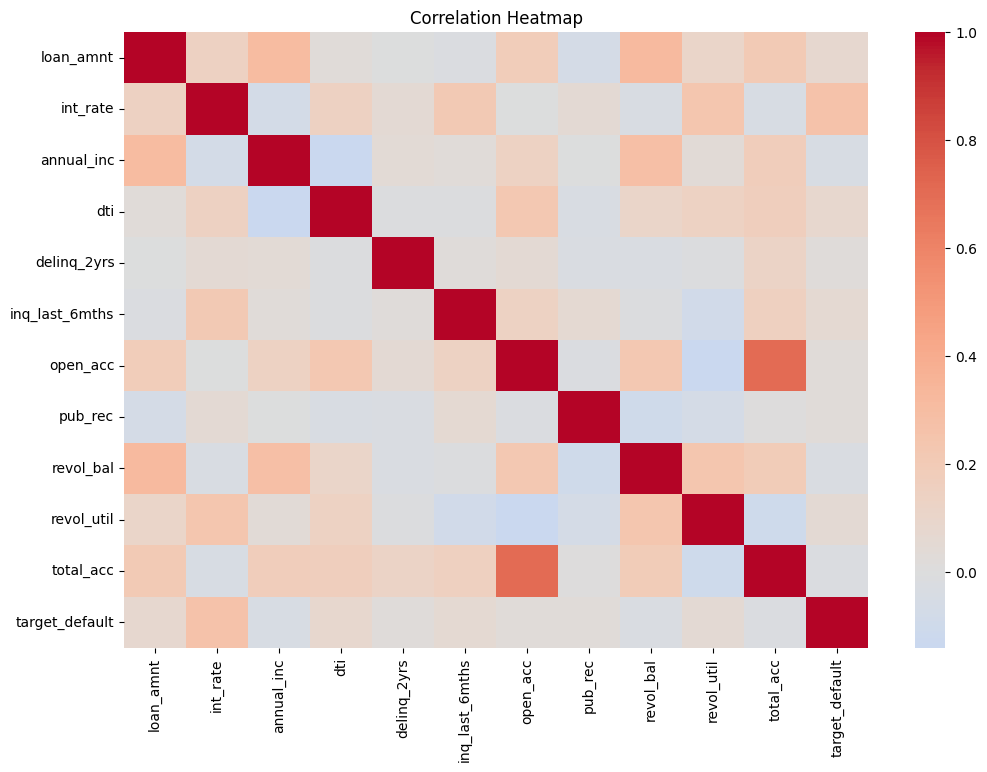

In [14]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## EAD summary

Defaults are concentrated among lower credit grades, higher interest-rate loans, longer-duration loans, and borrowers with elevated debt burdens